# 04 — Classification Models

Trains and evaluates three models to predict next-day price direction (up/down) for all 9 stocks using 5-fold walk-forward validation.

**Models:** Logistic Regression, SVM (RBF), Feedforward DNN (PyTorch)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_DIR     = "."
FEAT_DIR     = os.path.join(BASE_DIR, "data/features")
RESULTS_DIR  = os.path.join(BASE_DIR, "data/results")

TICKERS      = ["AAPL", "MSFT", "JPM", "GS", "JNJ", "PFE", "SPOT", "AMZN", "TSLA"]
FEATURE_COLS = [
    "SMA_5", "SMA_10", "SMA_20",
    "EMA_5", "EMA_10", "EMA_20",
    "RSI_14", "MACD", "MACD_Signal",
    "Volatility", "Volume_Change"
]

os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Helpers

In [2]:
def walk_forward_splits(df, n_splits=5, min_train_frac=0.5):
    n         = len(df)
    min_train = int(n * min_train_frac)
    test_size = (n - min_train) // n_splits
    splits    = []
    for i in range(n_splits):
        train_end  = min_train + i * test_size
        test_start = train_end
        test_end   = test_start + test_size
        if i == n_splits - 1:
            test_end = n
        splits.append((list(range(0, train_end)),
                       list(range(test_start, test_end))))
    return splits

def evaluate_classification(y_true, y_pred, fold=None):
    return {
        "Fold"     : fold,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

print("Helpers defined.")

Helpers defined.


## 2. Logistic Regression

In [3]:
print("Logistic Regression")

lr_results = []
all_y_true_lr, all_y_pred_lr = [], []

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values
    y      = df["Label_Class"].values
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model  = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        model.fit(X[tr], y[tr])
        y_pred = model.predict(X[te])

        metrics = evaluate_classification(y[te], y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_lr.extend(y[te])
        all_y_pred_lr.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  Accuracy: {fold_df['Accuracy'].mean():.4f}  F1: {fold_df['F1'].mean():.4f}")
    lr_results.extend(ticker_results)

lr_df      = pd.DataFrame(lr_results)
lr_summary = lr_df[["Accuracy", "Precision", "Recall", "F1"]].mean()
print(f"  Mean     Accuracy: {lr_summary['Accuracy']:.4f}  F1: {lr_summary['F1']:.4f}")
print("Logistic Regression complete.")

Logistic Regression
  AAPL   Accuracy: 0.4756  F1: 0.5652
  MSFT   Accuracy: 0.5077  F1: 0.6125
  JPM    Accuracy: 0.5397  F1: 0.6546
  GS     Accuracy: 0.5182  F1: 0.4795
  JNJ    Accuracy: 0.5123  F1: 0.3851
  PFE    Accuracy: 0.4603  F1: 0.5201
  SPOT   Accuracy: 0.5077  F1: 0.4721
  AMZN   Accuracy: 0.5167  F1: 0.3706
  TSLA   Accuracy: 0.4924  F1: 0.3471
  Mean     Accuracy: 0.5034  F1: 0.4896
Logistic Regression complete.


## 3. SVM (RBF kernel)

In [4]:
print("SVM (RBF kernel)")

svm_results = []
all_y_true_svm, all_y_pred_svm = [], []

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values
    y      = df["Label_Class"].values
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model  = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
        model.fit(X[tr], y[tr])
        y_pred = model.predict(X[te])

        metrics = evaluate_classification(y[te], y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_svm.extend(y[te])
        all_y_pred_svm.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  Accuracy: {fold_df['Accuracy'].mean():.4f}  F1: {fold_df['F1'].mean():.4f}")
    svm_results.extend(ticker_results)

svm_df      = pd.DataFrame(svm_results)
svm_summary = svm_df[["Accuracy", "Precision", "Recall", "F1"]].mean()
print(f"  Mean     Accuracy: {svm_summary['Accuracy']:.4f}  F1: {svm_summary['F1']:.4f}")
print("SVM complete.")

SVM (RBF kernel)
  AAPL   Accuracy: 0.4801  F1: 0.5104
  MSFT   Accuracy: 0.5275  F1: 0.6102
  JPM    Accuracy: 0.5000  F1: 0.5714
  GS     Accuracy: 0.5243  F1: 0.4747
  JNJ    Accuracy: 0.5259  F1: 0.5520
  PFE    Accuracy: 0.5032  F1: 0.3191
  SPOT   Accuracy: 0.4910  F1: 0.4715
  AMZN   Accuracy: 0.4862  F1: 0.4130
  TSLA   Accuracy: 0.4969  F1: 0.3969
  Mean     Accuracy: 0.5039  F1: 0.4799
SVM complete.


## 4. Feedforward DNN (PyTorch)

Architecture: Input(11) -> Dense(64) -> BatchNorm -> ReLU -> Dropout(0.3) -> Dense(32) -> BatchNorm -> ReLU -> Dropout(0.3) -> Dense(1) -> Sigmoid

In [5]:
class ClassifierDNN(nn.Module):
    def __init__(self, input_dim=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),         nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_classifier_dnn(X_train, y_train, epochs=50, batch_size=32, lr=1e-3):
    X_t       = torch.FloatTensor(X_train).to(device)
    y_t       = torch.FloatTensor(y_train).to(device)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    model     = ClassifierDNN(input_dim=X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    n_pos     = y_train.sum()
    n_neg     = len(y_train) - n_pos
    pos_weight= torch.tensor([n_neg / (n_pos + 1e-6)]).to(device)
    model.net[-1] = nn.Identity()
    criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        scheduler.step()
    model.net[-1] = nn.Sigmoid()
    return model


def predict_classifier_dnn(model, X_test, threshold=0.5):
    model.eval()
    with torch.no_grad():
        probs = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()
    return (probs >= threshold).astype(int)


print("DNN class defined.")

DNN class defined.


In [6]:
print("Feedforward DNN")

dnn_results = []
all_y_true_dnn, all_y_pred_dnn = [], []

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values.astype(np.float32)
    y      = df["Label_Class"].values.astype(np.float32)
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model  = train_classifier_dnn(X[tr], y[tr], epochs=50)
        y_pred = predict_classifier_dnn(model, X[te])

        metrics = evaluate_classification(y[te].astype(int), y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_dnn.extend(y[te].astype(int))
        all_y_pred_dnn.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  Accuracy: {fold_df['Accuracy'].mean():.4f}  F1: {fold_df['F1'].mean():.4f}")
    dnn_results.extend(ticker_results)

dnn_df      = pd.DataFrame(dnn_results)
dnn_summary = dnn_df[["Accuracy", "Precision", "Recall", "F1"]].mean()
print(f"  Mean     Accuracy: {dnn_summary['Accuracy']:.4f}  F1: {dnn_summary['F1']:.4f}")
print("DNN complete.")

Feedforward DNN
  AAPL   Accuracy: 0.4649  F1: 0.0518
  MSFT   Accuracy: 0.4709  F1: 0.1020
  JPM    Accuracy: 0.4436  F1: 0.0890
  GS     Accuracy: 0.4467  F1: 0.0941
  JNJ    Accuracy: 0.5214  F1: 0.3856
  PFE    Accuracy: 0.4969  F1: 0.6367
  SPOT   Accuracy: 0.4648  F1: 0.1179
  AMZN   Accuracy: 0.4803  F1: 0.0530
  TSLA   Accuracy: 0.5153  F1: 0.3770
  Mean     Accuracy: 0.4783  F1: 0.2119
DNN complete.


## 5. Results summary

In [7]:
results_table = pd.DataFrame({
    "Model"    : ["Logistic Regression", "SVM (RBF)", "DNN (PyTorch)"],
    "Accuracy" : [lr_summary["Accuracy"],  svm_summary["Accuracy"],  dnn_summary["Accuracy"]],
    "Precision": [lr_summary["Precision"], svm_summary["Precision"], dnn_summary["Precision"]],
    "Recall"   : [lr_summary["Recall"],    svm_summary["Recall"],    dnn_summary["Recall"]],
    "F1"       : [lr_summary["F1"],        svm_summary["F1"],        dnn_summary["F1"]],
}).set_index("Model").round(4)

print("Classification Results — Mean across all stocks and folds")
print(results_table.to_string())
print("\nBest per metric:")
for col in results_table.columns:
    best = results_table[col].idxmax()
    print(f"  {col:<12}: {best}  ({results_table[col].max():.4f})")

results_table.to_csv(os.path.join(RESULTS_DIR, "classification_results.csv"))
print("\nSaved to data/results/classification_results.csv")

Classification Results — Mean across all stocks and folds
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.5034     0.5138  0.5677  0.4896
SVM (RBF)              0.5039     0.5387  0.5096  0.4799
DNN (PyTorch)          0.4783     0.3884  0.2307  0.2119

Best per metric:
  Accuracy    : SVM (RBF)  (0.5039)
  Precision   : SVM (RBF)  (0.5387)
  Recall      : Logistic Regression  (0.5677)
  F1          : Logistic Regression  (0.4896)

Saved to data/results/classification_results.csv


## 6. Confusion matrices

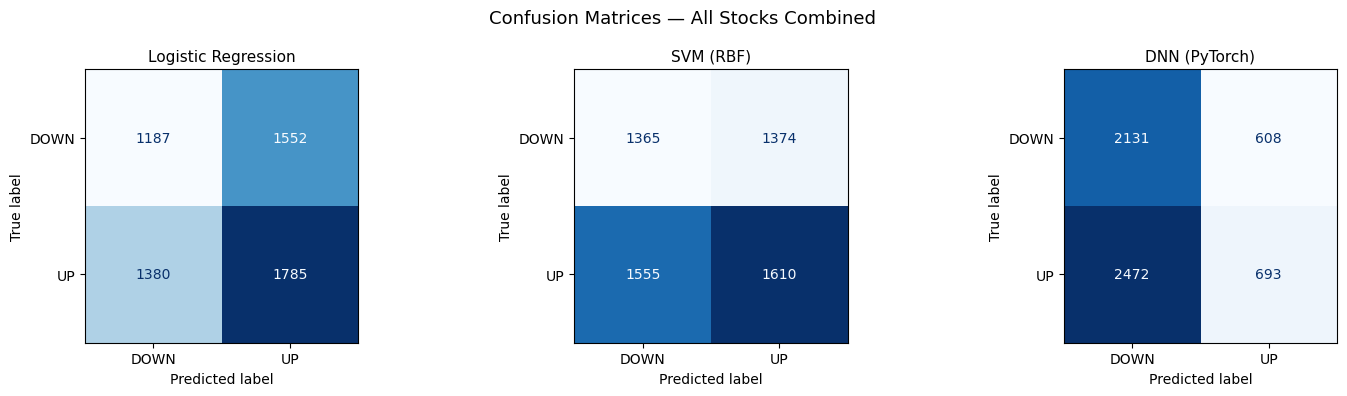

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_true, y_pred) in zip(axes, [
    ("Logistic Regression", all_y_true_lr,  all_y_pred_lr),
    ("SVM (RBF)",           all_y_true_svm, all_y_pred_svm),
    ("DNN (PyTorch)",       all_y_true_dnn, all_y_pred_dnn),
]):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["DOWN", "UP"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.suptitle("Confusion Matrices — All Stocks Combined", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "classification_confusion_matrices.png"), dpi=120, bbox_inches="tight")
plt.show()

## 7. F1 score by stock and model

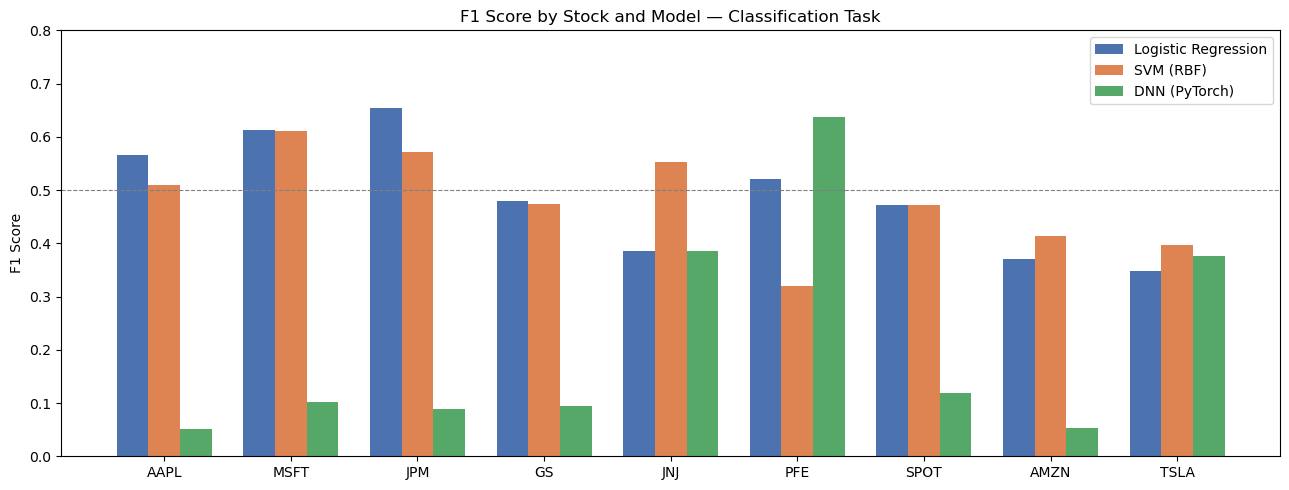

Notebook 04 complete — classification results saved.


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
x       = np.arange(len(TICKERS))
width   = 0.25

lr_f1s  = [pd.DataFrame(lr_results).query(f"Ticker=='{t}'")["F1"].mean()  for t in TICKERS]
svm_f1s = [pd.DataFrame(svm_results).query(f"Ticker=='{t}'")["F1"].mean() for t in TICKERS]
dnn_f1s = [pd.DataFrame(dnn_results).query(f"Ticker=='{t}'")["F1"].mean() for t in TICKERS]

ax.bar(x - width, lr_f1s,  width, label="Logistic Regression", color="#4C72B0")
ax.bar(x,         svm_f1s, width, label="SVM (RBF)",           color="#DD8452")
ax.bar(x + width, dnn_f1s, width, label="DNN (PyTorch)",       color="#55A868")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Stock and Model — Classification Task")
ax.set_ylim(0, 0.8)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "classification_f1_by_stock.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Notebook 04 complete — classification results saved.")